# Agent Architecture

### THE PLAN-DO-LOOP

#### BUIDLING A LANGGRAPH AGENT

In [1]:
import ast
from typing import Annotated, TypedDict
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_ollama import OllamaLLM
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def calculator(query: str) -> str:
    """A simple calculator tool. Input should be a mathematical expression."""
    return ast.literal_eval(query)


search = DuckDuckGoSearchRun()
tools = [search, calculator]
model = OllamaLLM(model="llama3.2:3b")


class State(TypedDict):
    messages: Annotated[list, add_messages]


def model_node(state: State) -> State:
    res = model.invoke(state["messages"])
    return {"messages": res}


builder = StateGraph(State)

builder.add_node("model", model_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "model")
builder.add_conditional_edges("model", tools_condition)
builder.add_edge("tools", "model")

graph = builder.compile()

input = {
    "messages": [
        HumanMessage(
            "how old was the 4 th prime minister of the India and when he died?"
        )
    ]
}
for chunk in graph.stream(input):
    print(chunk)

{'model': {'messages': 'The 4th Prime Minister of India was Jawaharlal Nehru. He served from August 15, 1947 to May 27, 1964.\n\nJawaharlal Nehru was born on November 14, 1889, and he died on May 27, 1964 at the age of 74.'}}


**using two tools in this example:- search tool and calculator tool**

``ToolNode``
1. Servers as a graph node that executes the tool call requested in the latest AI message
2. Return a `ToolMessage` containing the results of each tool call
3. Handles exceptions raised by tools by packaging the error message into a `ToolMessage`, which is then passed back to the LLM 

``tools_conditions``
**A conditional edge functions.**
1. it checks the latest AI message in the state.
* if tools call are present -> routes to the tools node
* if no tools calls -> ends the graph

In [2]:
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

#### ALWAYS CALLING A TOOL FIRST

In [6]:
import ast
from typing import Annotated, TypedDict
from uuid import uuid4

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import AIMessage, HumanMessage, ToolCall
from langchain_core.tools import tool
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_experimental.llms.ollama_functions import OllamaFunctions


@tool
def calculator(query: str) -> str:
    """A simple calculator tool. Input should be a mathematical expression."""
    return ast.literal_eval(query)


search = DuckDuckGoSearchRun()
tools = [search, calculator]
model = OllamaFunctions(model="llama3.2:3b", temperature=0.1).bind_tools(tools)


class State(TypedDict):
    messages: Annotated[list, add_messages]


def model_node(state: State) -> State:
    res = model.invoke(state["messages"])
    return {"messages": res}


def first_model(state: State) -> State:
    query = state["messages"][-1].content
    search_tool_call = ToolCall(
        name="duckduckgo_search", args={"query": query}, id=uuid4().hex
    )
    return {"messages": AIMessage(content="", tool_calls=[search_tool_call])}


builder = StateGraph(State)
builder.add_node("first_model", first_model)
builder.add_node("model", model_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "first_model")
builder.add_conditional_edges("model", tools_condition)
builder.add_edge("first_model", "tools")
builder.add_edge("tools", "model")

graph = builder.compile()

input = {
    "messages": [
        HumanMessage("how old was the 4th president of United State when he died?")
    ]
}

/var/folders/5t/q_d9trtj45bb86db6cbv_whr0000gn/T/ipykernel_2773/3397777082.py:22: LangChainDeprecationWarning: The class `OllamaFunctions` was deprecated in LangChain 0.0.64 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  model = OllamaFunctions(model="llama3.2:3b", temperature=0.1).bind_tools(tools)


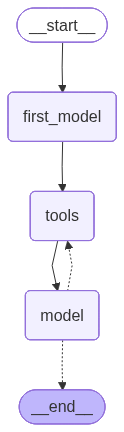

In [7]:
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

#### DEALING WITH MANY TOOLS

In [11]:
import ast
from typing import Annotated,TypedDict
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.vectorstores.in_memory import InMemoryVectorStore
from langchain_ollama import OllamaLLM,OllamaEmbeddings
from langgraph.graph import START , StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

@tool
def calculator(query:str)->str:
    """A simple calculator tool. Input should be a mathematical expression."""
    return ast.literal_eval(query)

search = DuckDuckGoSearchRun()
tools = [search,calculator]
model = OllamaLLM(model = "llama3.2")
embeddings = OllamaEmbeddings(model="mxbai-embed-large:latest")

tools_retriever = InMemoryVectorStore.from_documents(
    [Document(tool.description,metadata={"name":tool.name}) for tool in tools],
    embeddings,
).as_retriever()

class State(TypedDict):
    messages:Annotated[list,add_messages]
    selected_tools:list[str]


def model_node(state: State)->State:
    selected_tools = [tool for tool in tools if tool.name in state["selected_tools"]]
    res = model.bind_tools(selected_tools).invoke(state["messages"])
    return {"messages":res}

def select_tools(state: State)->State:
    query = state["messages"][-1].content
    tools_docs = tools_retriever.invoke(query)
    return {"selected_tools":[doc.metadata["name"] for doc in tools_docs]}

builder = StateGraph(State)
builder.add_node("model_node",model_node)
builder.add_node("select_tools",select_tools)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"select_tools")
builder.add_edge("select_tools","model_node")
builder.add_conditional_edges("model_node",tools_condition)
builder.add_edge("tools","model_node")

graph = builder.compile()

input={
    "messages":[
        HumanMessage(
            "how old the 30th president of United state when he died?"
        )
    ]
}

In [ ]:
from IPython.display import Image, display
png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))